In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

In [2]:
df = pd.read_csv("adult.csv", delimiter=',')

In [3]:
data_cleaned = df.replace('?', np.nan)
data_cleaned['income'] = data_cleaned['income'].apply(lambda x: 1 if x == '>50K' else 0)
data_dropped = data_cleaned.dropna()

In [4]:
data_cleaned = data_dropped.drop(columns=['educational-num'])

In [5]:
for col in data_cleaned.select_dtypes(include=np.number).columns:
    df_encoded = pd.get_dummies(data_cleaned, drop_first=True)

In [6]:
correlation_matrix = df_encoded.corr()
correlation_with_target = correlation_matrix['income'].sort_values(ascending=False)
print(correlation_with_target)

selected_features = correlation_with_target[correlation_with_target.abs() > 0.2].index.tolist()
selected_features.remove('income')  
print("Вибрані ознаки для моделі:", selected_features)

income                               1.000000
marital-status_Married-civ-spouse    0.446192
age                                  0.237040
hours-per-week                       0.227199
capital-gain                         0.221034
                                       ...   
relationship_Unmarried              -0.147262
occupation_Other-service            -0.165428
relationship_Not-in-family          -0.195561
relationship_Own-child              -0.222635
marital-status_Never-married        -0.319536
Name: income, Length: 96, dtype: float64
Вибрані ознаки для моделі: ['marital-status_Married-civ-spouse', 'age', 'hours-per-week', 'capital-gain', 'gender_Male', 'occupation_Exec-managerial', 'relationship_Own-child', 'marital-status_Never-married']


In [12]:
X_1 = df_encoded[['marital-status_Married-civ-spouse', 'age', 'hours-per-week', 'capital-gain', 'gender_Male', 'occupation_Exec-managerial', 'relationship_Own-child', 'marital-status_Never-married']]
y_1 = df_encoded['income']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

In [15]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Точність моделі Decision Tree на тестовій вибірці: {accuracy:.2f}")

Точність моделі Decision Tree на тестовій вибірці: 0.81


Налаштування гіперпараметрів дерева

In [19]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, test_index) in enumerate(kf.split(X_1)):
    print(f"Розбиття {fold + 1}:")
    print(f"  Індекси навчальної вибірки: {train_index[:5]}...") 
    print(f"  Індекси тестової вибірки: {test_index[:5]}...")


Розбиття 1:
  Індекси навчальної вибірки: [0 2 3 5 6]...
  Індекси тестової вибірки: [ 1  4  7 13 23]...
Розбиття 2:
  Індекси навчальної вибірки: [1 2 3 4 5]...
  Індекси тестової вибірки: [ 0  6 17 30 33]...
Розбиття 3:
  Індекси навчальної вибірки: [0 1 2 4 5]...
  Індекси тестової вибірки: [ 3  8 14 24 25]...
Розбиття 4:
  Індекси навчальної вибірки: [0 1 2 3 4]...
  Індекси тестової вибірки: [ 5 11 15 18 19]...
Розбиття 5:
  Індекси навчальної вибірки: [0 1 3 4 5]...
  Індекси тестової вибірки: [ 2  9 10 12 16]...


In [23]:
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=dt_model,
    param_grid=param_grid,
    cv=5,  # 5-кратна крос-валідація
    scoring='accuracy', 
    verbose=1,
    n_jobs=-1  
)

grid_search.fit(X_1, y_1)

print(f"Найкращі гіперпараметри: {grid_search.best_params_}")
print(f"Точність з найкращими параметрами: {grid_search.best_score_:.2f}")

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Точність на тестовій вибірці: {test_accuracy:.2f}")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Найкращі гіперпараметри: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Точність з найкращими параметрами: 0.82
Точність на тестовій вибірці: 0.83


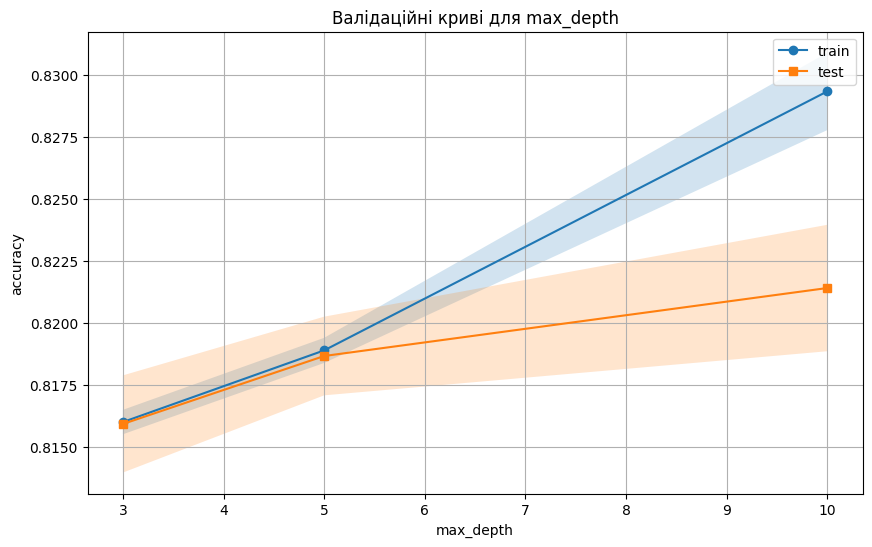

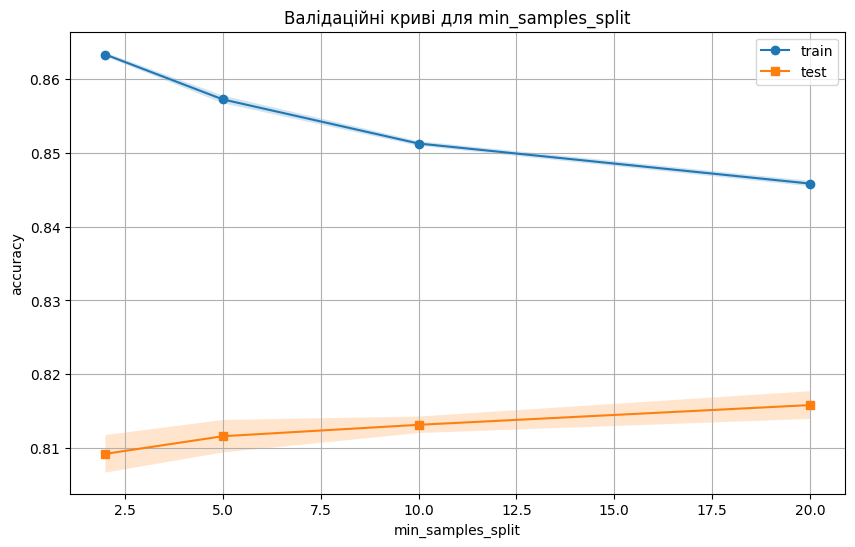

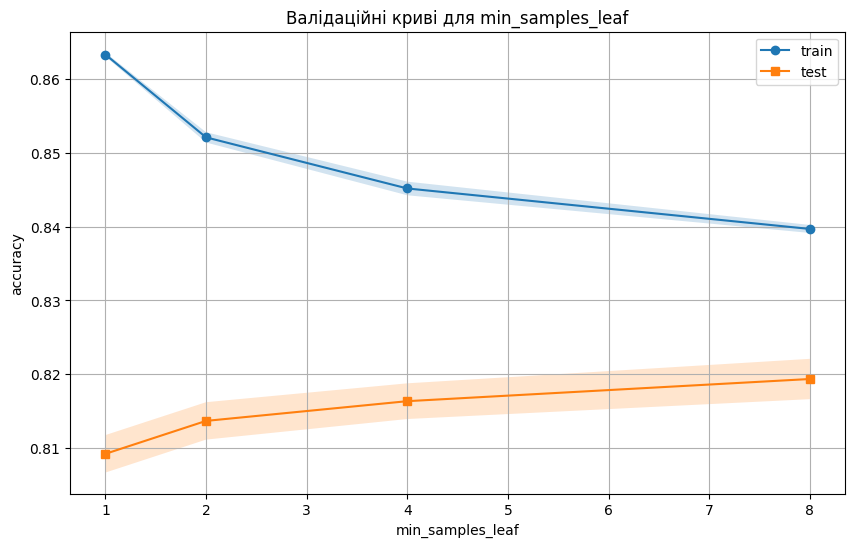

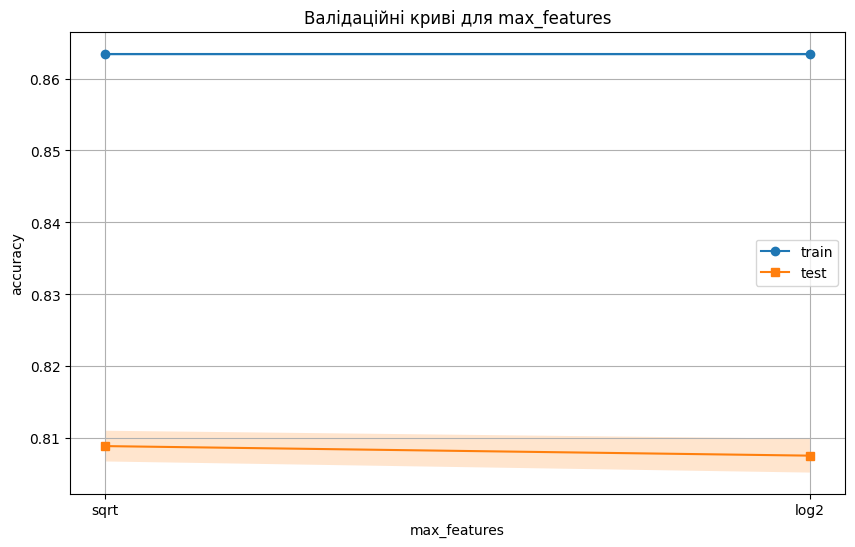

In [34]:
param_ranges = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': [ 'sqrt', 'log2']
}

def plot_validation_curve(estimator, X, y, param_name, param_range):
    train_scores, test_scores = validation_curve(
        estimator,
        X, y,
        param_name=param_name,
        param_range=param_range,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(param_range, train_mean, label="train", marker='o')
    plt.plot(param_range, test_mean, label="test", marker='s')
    plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2)
    plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2)
    plt.title(f"Валідаційні криві для {param_name}")
    plt.xlabel(param_name)
    plt.ylabel("accuracy")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

dt_model = DecisionTreeClassifier(random_state=42)

for param_name, param_range in param_ranges.items():
    plot_validation_curve(dt_model, X_1, y_1, param_name, param_range)


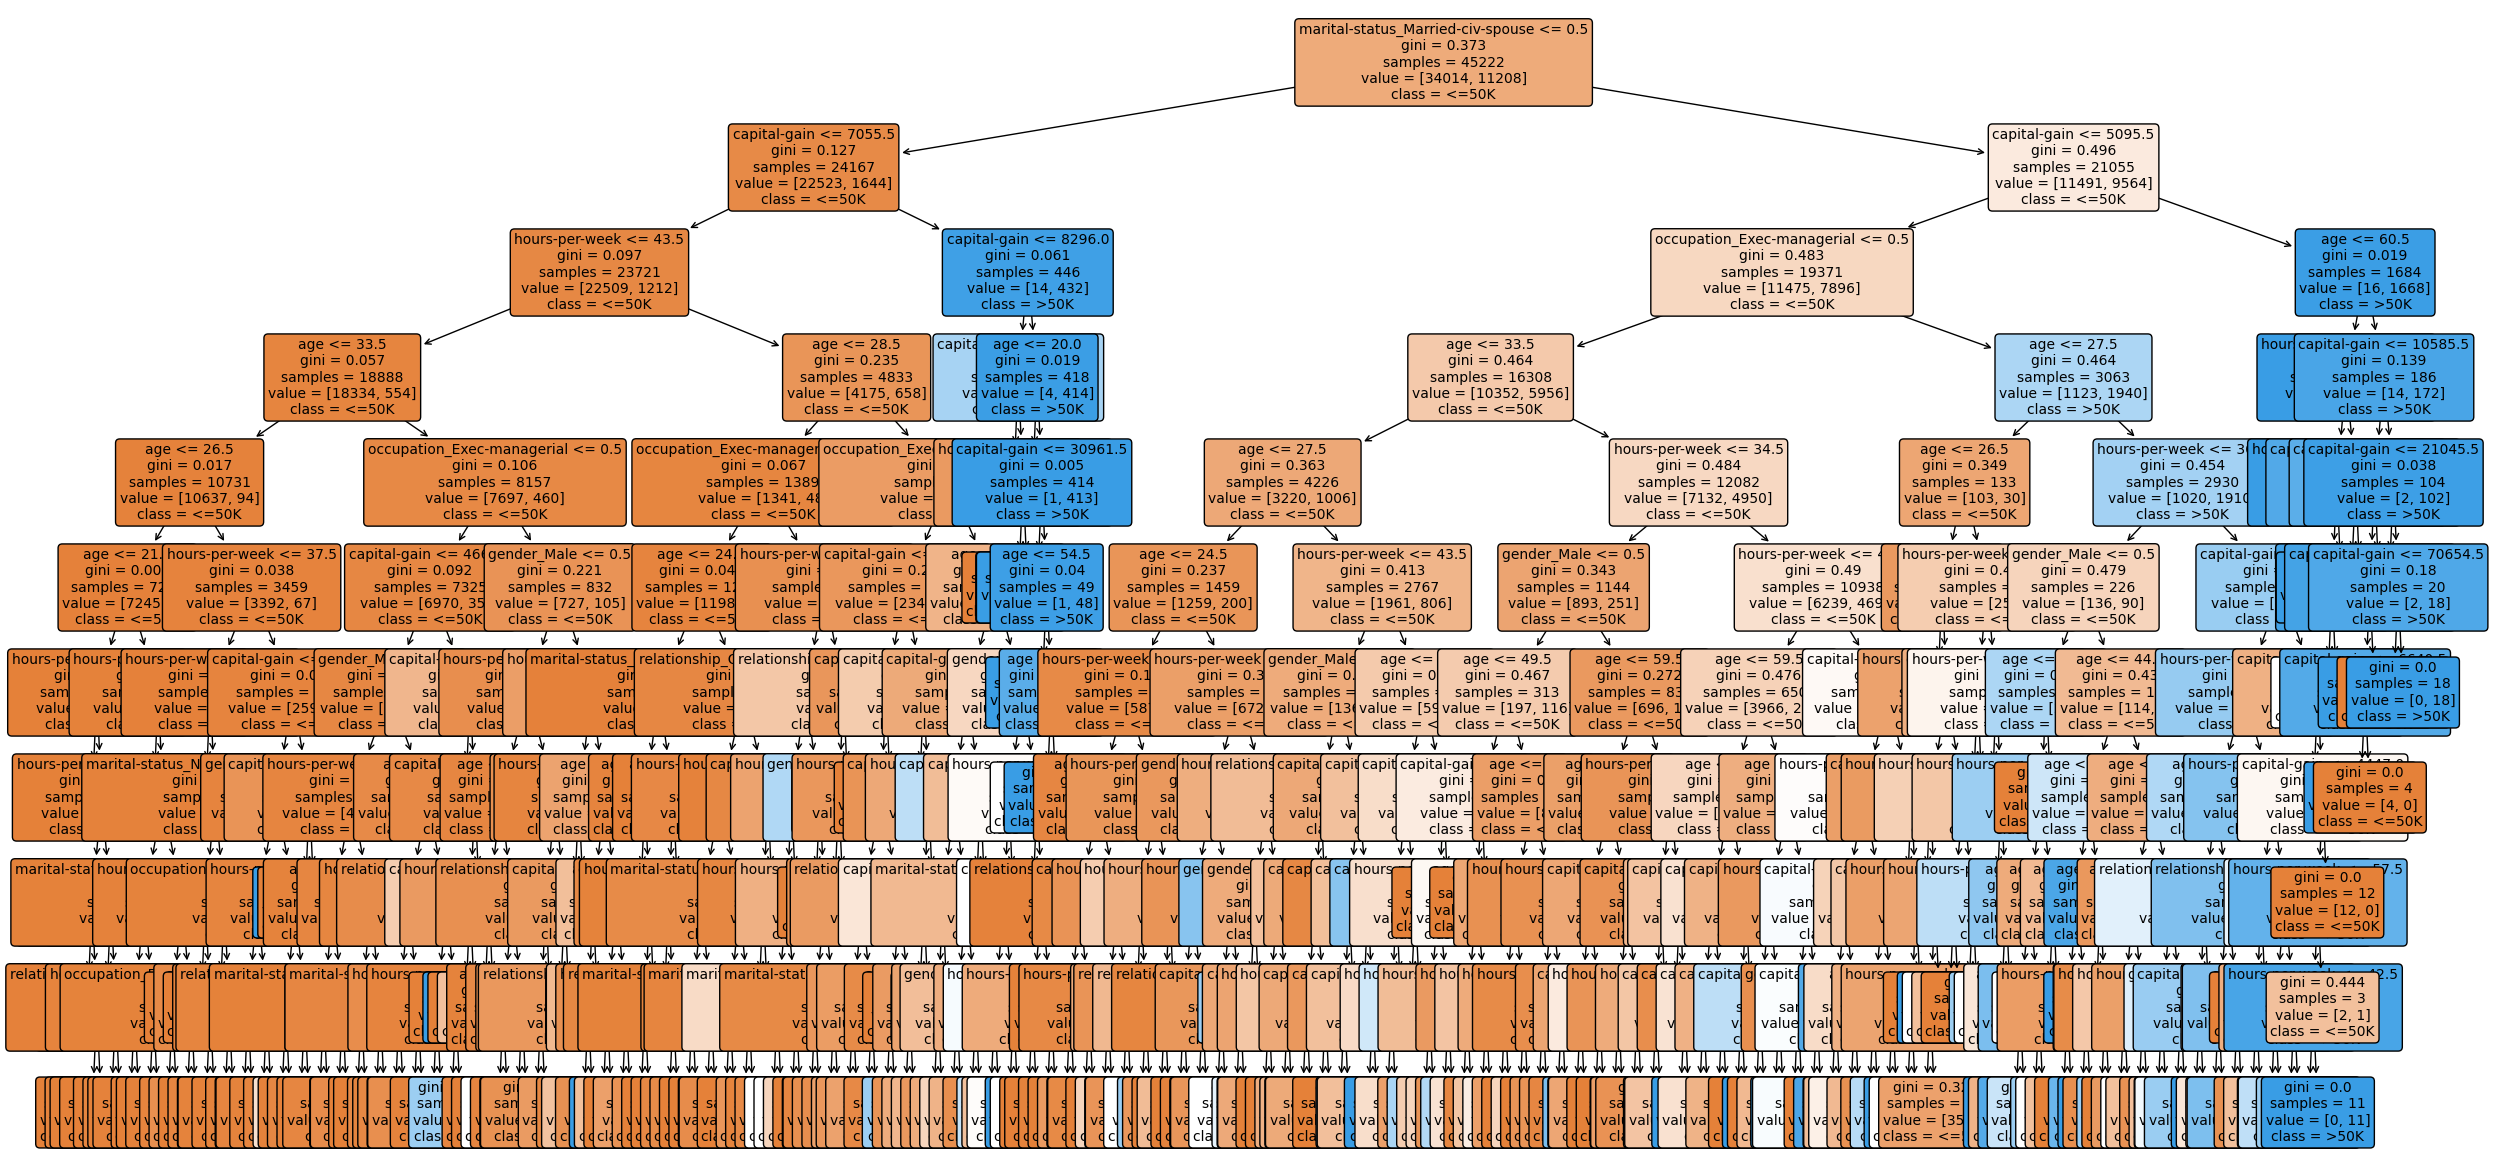

Важливість ознак:
marital-status_Married-civ-spouse: 0.4890
capital-gain: 0.3056
age: 0.0784
occupation_Exec-managerial: 0.0588
hours-per-week: 0.0565
gender_Male: 0.0086
relationship_Own-child: 0.0026
marital-status_Never-married: 0.0005


In [26]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 15))
plot_tree(
    best_model,
    feature_names=X_1.columns,
    class_names=['<=50K', '>50K'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

importances = best_model.feature_importances_
feature_importance = sorted(zip(X_1.columns, importances), key=lambda x: x[1], reverse=True)

print("Важливість ознак:")
for feature, importance in feature_importance:
    print(f"{feature}: {importance:.4f}")


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)
print("Accuracy (default):", accuracy_score(y_test, y_pred_default))
print("\nClassification Report (default):\n", classification_report(y_test, y_pred_default))

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

rf_best = grid_search.best_estimator_
y_pred_best = rf_best.predict(X_test)

print("Accuracy (best):", accuracy_score(y_test, y_pred_best))
print("\nClassification Report (best):\n", classification_report(y_test, y_pred_best))


Accuracy (default): 0.8126036484245439

Classification Report (default):
               precision    recall  f1-score   support

           0       0.85      0.92      0.88      6842
           1       0.66      0.48      0.56      2203

    accuracy                           0.81      9045
   macro avg       0.75      0.70      0.72      9045
weighted avg       0.80      0.81      0.80      9045

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Accuracy (best): 0.8291873963515755

Classification Report (best):
               precision    recall  f1-score   support

           0       0.85      0.94      0.89      6842
           1       0.73      0.47      0.57      2203

    accuracy                           0.83      9045
   macro avg       0.79      0.71      0.73      9045
weighted avg       0.82      0.83      0.82      9045



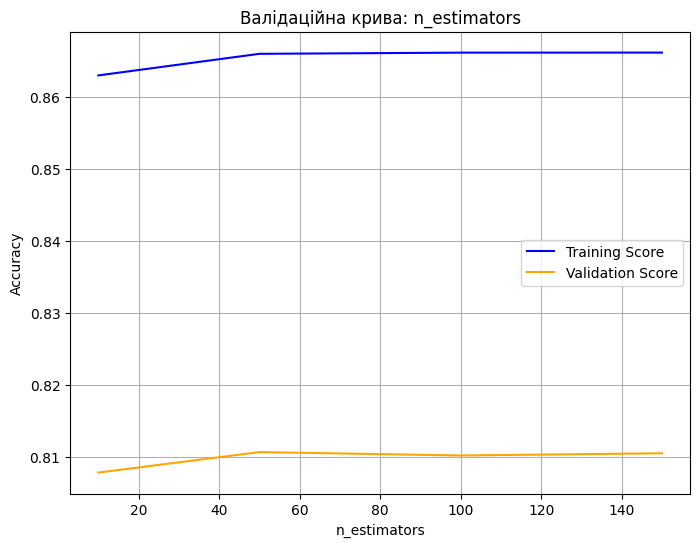

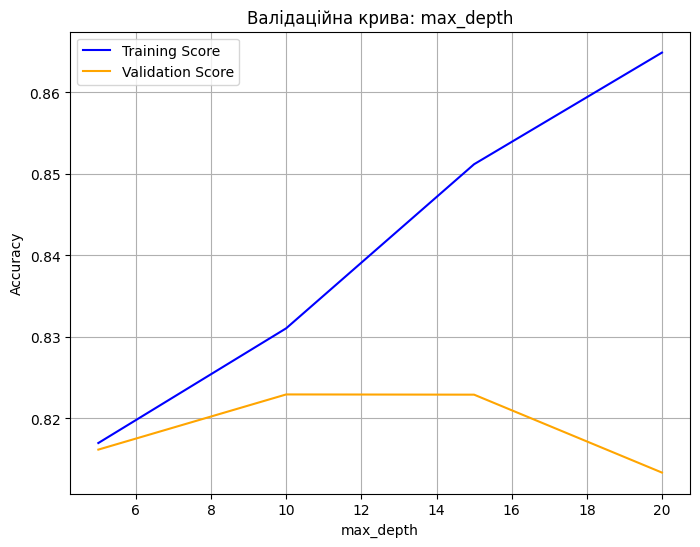

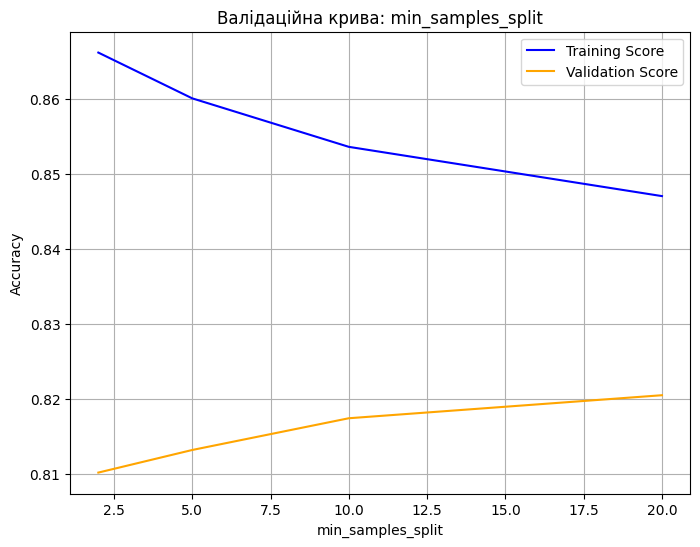

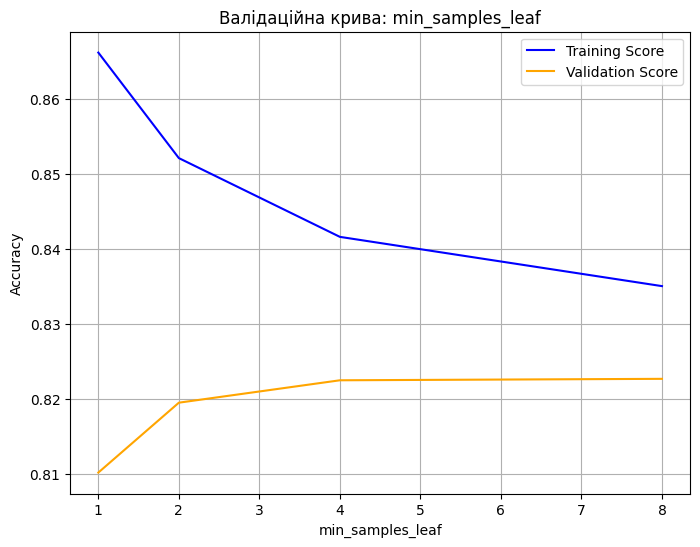

In [29]:
param_range_estimators = [10, 50, 100, 150]
param_range_depth = [5, 10, 15, 20]
param_range_split = [2, 5, 10, 20]
param_range_leaf = [1, 2, 4, 8]

def plot_validation_curve(param_name, param_range, title):
    train_scores, test_scores = validation_curve(
        RandomForestClassifier(random_state=42),
        X_train,
        y_train,
        param_name=param_name,
        param_range=param_range,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(param_range, train_mean, label="Training Score", color="blue")
    plt.plot(param_range, test_mean, label="Validation Score", color="orange")
    plt.title(title)
    plt.xlabel(param_name)
    plt.ylabel("Accuracy")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

plot_validation_curve('n_estimators', param_range_estimators, "Валідаційна крива: n_estimators")
plot_validation_curve('max_depth', param_range_depth, "Валідаційна крива: max_depth")
plot_validation_curve('min_samples_split', param_range_split, "Валідаційна крива: min_samples_split")
plot_validation_curve('min_samples_leaf', param_range_leaf, "Валідаційна крива: min_samples_leaf")


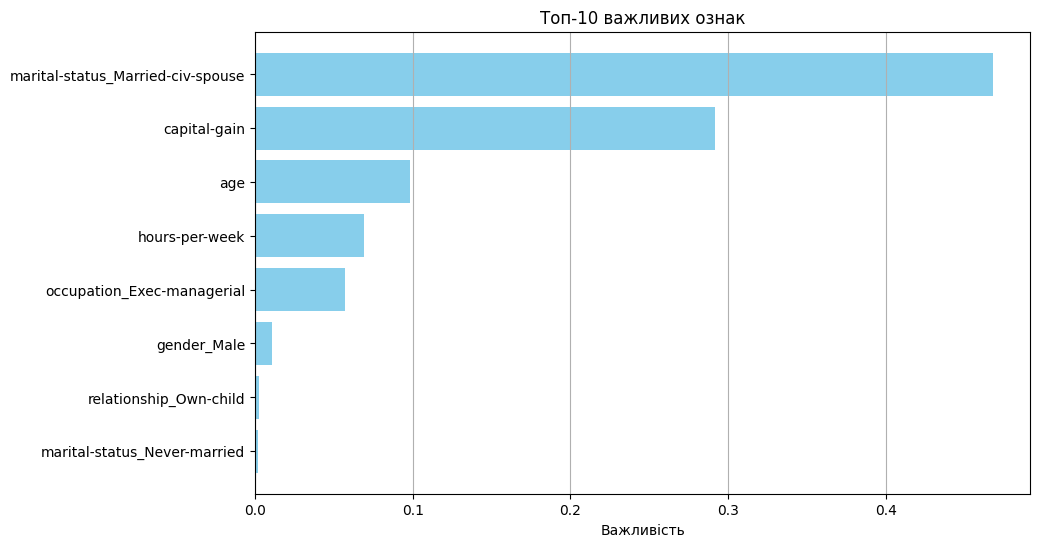

In [30]:
importances = rf_best.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='skyblue')
plt.title("Топ-10 важливих ознак")
plt.xlabel("Важливість")
plt.gca().invert_yaxis()  
plt.grid(axis='x')
plt.show()


KNN Accuracy: 0.8060
KNN Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.88      6842
           1       0.63      0.50      0.56      2203

    accuracy                           0.81      9045
   macro avg       0.74      0.70      0.72      9045
weighted avg       0.79      0.81      0.80      9045

Decision Tree Accuracy: 0.8207
Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89      6842
           1       0.79      0.36      0.49      2203

    accuracy                           0.82      9045
   macro avg       0.81      0.66      0.69      9045
weighted avg       0.82      0.82      0.79      9045

Random Forest Accuracy: 0.8292
Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.94      0.89      6842
           1       0.73      0.47      0.57      2

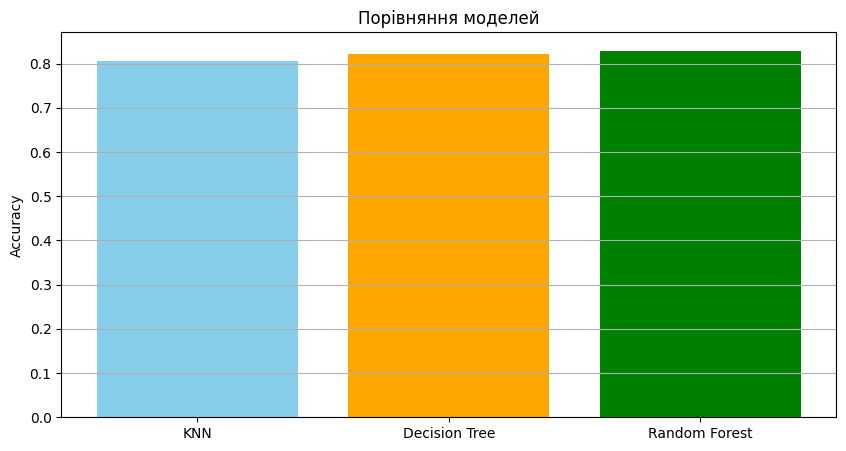

In [31]:
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

models = {
    "KNN": knn,
    "Decision Tree": dt,
    "Random Forest": rf_best
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(f"{name} Classification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values(), color=['skyblue', 'orange', 'green'])
plt.title("Порівняння моделей")
plt.ylabel("Accuracy")
plt.grid(axis='y')
plt.show()
